# Protein Prediction Model

## Setup

### Imports

In [104]:
import tensorflow as tf
import keras
import numpy as np
import matplotlib.pyplot as plt
import os, glob, pathlib
import pandas as pd
import datetime as dt
import time

### Data Aquisition

Data needs to be imported from its raw .xls format then processed into separate dataframes for each protein's items.

In [105]:
# TODO: Pull in all .xls files in the data directory and process them into their respective dictionaries of dataframes.
data_path = pathlib.Path.cwd() / "data" / "03_16_03_21_Nuggets.xls"  # Path to the Excel file containing the sales data
df = pd.read_excel(data_path)

WARNING *** file size (120995) not 512 + multiple of sector size (512)
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero


### Data Formatting

Data needs to be cleaned from report generator formatting and split into usable dataframes.

In [106]:
def convert_to_24h(time_str: str) -> dt.datetime:
    '''
    Convert a time string in the format "HH:MM AM/PM - HH:MM AM/PM" 
    to a datetime.time object in 24-hour format.

    Args:
        time_str (str): The time string to convert.

    Returns:
        dt.time: The start time in 24-hour format.
    '''
    time_components = time_str.split()  # Split the time string into components by whitespace
    start_time = time_components[0]     # The first component is the start time (e.g., "10:00")
    am_pm = time_components[3]          # The fourth component is the AM/PM indicator for the end time (e.g., "AM" or "PM")
    hours, minutes = map(int, start_time.split(':'))    # Split the start time into hours and minutes and convert to integers
    if am_pm == 'PM' and hours != 12:       # If the time is in PM and not 12 PM, add 12 to convert to 24-hour format
        hours += 12
    elif am_pm == 'AM' and hours == 12:     # If the time is 12 AM, set hours to 0 to convert to 24-hour format
        hours = 0
    return dt.datetime.combine(dt.date.today(), dt.time(hour=hours, minute=minutes))  # Return the start time as a datetime.time object in 24-hour format

In [107]:
df = df.iloc[6:, :]         # Drop the first 6 rows which contain metadata and are not part of the actual data
df = df.drop(df.columns[1], axis=1) # Drop the second column containing only the word "Time"
df = df[df.iloc[:, 0] != "Sales Mix Time Interval Report"]  # Drop rows where the first column contains "Sales Mix Time Interval Report"
df = df[df.iloc[:, 0] != "Store: Indian Trail FSU, 02965"]  # Drop rows where the first column contains "Store: Indian Trail FSU, 02965"
df = df[df.iloc[:, 2] != "Totals:"] # Drop rows where the fourth column contains "Totals:"
df = df.dropna(axis=1, how='all')   # Drop columns where all values are NaN (holdovers from PDF formatting)
df.rename(columns={df.columns[0]: 'Item', df.columns[1]: 'Time Interval', df.columns[2]: 'Monday',
                   df.columns[3]: 'Tuesday', df.columns[4]: 'Wednesday', df.columns[5]: 'Thursday',
                   df.columns[6]: 'Friday', df.columns[7]: 'Saturday'}, inplace=True)
for col in df.columns[2:]:    # 2:-1 to skip the 'Item', 'Time Interval', and 'Start Time' columns, which are not sales data columns
    df[col] = pd.to_numeric(df[col], errors='coerce')   # Convert the sales data columns to numeric, coercing errors to NaN
df = df.dropna(how='all')   # Drop rows where all values are NaN
df.reset_index(drop=True, inplace=True) # Reset the index of the dataframe after dropping rows

In [108]:
# TODO: Map time intervals to integers to facilitate model training, and store the mapping in a dictionary for later use in prediction.
# Pull start times from the time interval column and convert to 24-hour format.
time_dict : dict[dt.time, int] = {}  # Initialize an empty dictionary to store the mapping of time intervals to integers
# Create a mapping of dt.time objects starting at 10:30 AM and ending at 10:00 PM in 15 minute intervals to integers starting at 0 and ending at 47 (32 intervals in total)
current_time = dt.time(hour=10, minute=30)  # Start time at 10:30 AM
current_time = dt.datetime.combine(dt.date.today(), current_time)  # Combine the current time with today's date to create a datetime object for easier manipulation
while current_time < dt.datetime.combine(dt.date.today(), dt.time(hour=22, minute=0)):  # End time at 10:00 PM
    time_dict[current_time.time()] = len(time_dict)  # Map the current time to the next integer in the sequence
    current_time += dt.timedelta(minutes=15)  # Increment the current time by 15 minutes

df['Time Interval'] = df.iloc[:, 1].map(lambda x: convert_to_24h(x) if pd.notnull(x) else np.nan)
df['Time Interval'] = df['Time Interval'].map(lambda x: time_dict.get(x.time(), np.nan) if pd.notnull(x) else np.nan)
df = df[df['Time Interval'].notnull() | df['Item'].notnull()]  # Drop rows where the 'Time Interval' column has null values after mapping
df.reset_index(drop=True, inplace=True) # Reset the index of the dataframe after dropping rows

In [109]:
df_dict : dict[str, pd.DataFrame] = {}  # Initialize an empty dictionary to store the dataframes for each item
for item in df['Item'].unique():        # Only create dataframes for unique, non-null item names in the 'Item' column
    if pd.notnull(item):
        df_dict[item] = df[df['Item'] == item].copy()
name_idx_start = 0
name_idx_end = 0
for index, row in df.iterrows():        # Grab each section of the dataframe corresponding to each item and store it in the dictionary with the item name as the key
    if pd.notnull(row['Item']):
        if name_idx_end != 0:           # First iteration guard
            df_dict[str(df.iloc[name_idx_start, 0])] = df.iloc[name_idx_start + 1:name_idx_end, :].copy()
            print(df_dict[str(df.iloc[name_idx_start, 0])])
        name_idx_start = name_idx_end       # Move the start index to the current end index for the next item section
        name_idx_end = name_idx_start + 1   # Move the end index to the next row to start looking for the next item name
    else:                               # If the current row does not contain an item name, move the end index down to continue looking for the next item name
        name_idx_end += 1
        continue

# Process the last item after the loop finishes
if name_idx_end != 0:  # Only process if at least one item was found
    df_dict[str(df.iloc[name_idx_start, 0])] = df.iloc[name_idx_start + 1:name_idx_end, :].copy()
    print(df_dict[str(df.iloc[name_idx_start, 0])])

for key in df_dict.keys():  # Adjust each dataframe to keep only the relevant data.
    df_dict[key].drop(df_dict[key].columns[0], axis=1, inplace=True)    # Item name and days of the week are stored in dataframe metadata, so drop the first two rows which contain this information
    df_dict[key]['Time Interval'] = df_dict[key]['Time Interval'].astype(int)  # Cast the time interval column to integers
    df_dict[key].reset_index(drop=True, inplace=True)                   # Reset the index of the dataframe after dropping rows and columns

   Item  Time Interval  Monday  Tuesday  Wednesday  Thursday  Friday  Saturday
1   NaN            0.0     NaN      NaN        NaN       NaN     NaN       NaN
2   NaN            1.0     NaN      NaN        NaN       NaN     NaN       NaN
3   NaN            2.0     NaN      NaN        NaN       NaN     2.0       NaN
4   NaN            3.0     NaN      NaN        NaN       NaN     NaN       NaN
5   NaN            4.0     NaN      NaN        NaN       NaN     NaN       NaN
6   NaN            5.0     NaN      NaN        NaN       NaN     NaN       NaN
7   NaN            6.0     NaN      NaN        NaN       NaN     NaN       NaN
8   NaN            7.0     NaN      NaN        NaN       NaN     NaN       NaN
9   NaN            8.0     NaN      NaN        NaN       NaN     NaN       NaN
10  NaN            9.0     NaN      NaN        NaN       NaN     NaN       NaN
11  NaN           10.0     NaN      NaN        NaN       NaN     NaN       NaN
12  NaN           11.0     NaN      NaN        NaN  

In [110]:
for key in df_dict.keys():
    # Ensure that all mapped time intervals are present in the dataframe, and if not, add rows with NaN values for the sales data columns for those time intervals
    for time_interval in time_dict.values():
        if time_interval not in df_dict[key]['Time Interval'].values:
            new_row = {'Time Interval': time_interval}
            df_dict[key] = pd.concat([df_dict[key], pd.DataFrame([new_row])], ignore_index=True)  # Add the new row to the dataframe



for key in df_dict.keys():  # Final check to ensure that all dataframes have the same time intervals and are sorted by time interval
    assert set(df_dict[key]['Time Interval'].values) == set(time_dict.values()), f"Dataframe for item '{key}' is missing some time intervals."
    df_dict[key].sort_values(by='Time Interval', inplace=True)
    for col in df_dict[key].columns[1:]:    # 1: to skip the 'Time Interval' column, which is not sales data
        df_dict[key][col] = pd.to_numeric(df_dict[key][col], errors='coerce').fillna(0).astype(int)   # Ensure that all sales data columns are numeric, coercing errors to NaN
    df_dict[key].reset_index(drop=True, inplace=True)

print(df_dict)  # Print the dictionary of dataframes to verify that the data has been processed correctly

{'Nugget, 1 Count':     Time Interval  Monday  Tuesday  Wednesday  Thursday  Friday  Saturday
0               0       0        0          0         0       0         0
1               1       0        0          0         0       0         0
2               2       0        0          0         0       2         0
3               3       0        0          0         0       0         0
4               4       0        0          0         0       0         0
5               5       0        0          0         0       0         0
6               6       0        0          0         0       0         0
7               7       0        0          0         0       0         0
8               8       0        0          0         0       0         0
9               9       0        0          0         0       0         0
10             10       0        0          0         0       0         0
11             11       0        0          0         0       0         0
12             12 

    Time Interval  Monday  Tuesday  Wednesday  Thursday  Friday  Saturday
0               0       5       19         17         6      19        13
1               1      14        9         12        17      19        30
2               2      16       16         17        16      19        20
3               3      26       11         14        26      20        45
4               4      16       25         25        22      24        39
5               5      23       20         13        24      19        62
6               6      28       18         30        28      37        67
7               7      34       37         20        39      51        40
8               8      26       29         23        38      46        39
9               9      31       26         19        28      36        35
10             10      32       28         14        24      28        30
11             11      17       30         20        19      38        29
12             12      23       24    

Text(0.5, 0, 'Sales')

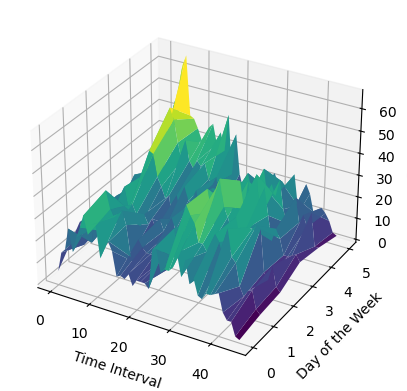

In [111]:
summed_df = pd.DataFrame()  # Initialize an empty dataframe to store the summed sales data for each time interval across all items
for key in df_dict.keys():
    if summed_df.empty:  # If the summed_df is empty, initialize it with the first dataframe
        summed_df = df_dict[key].copy()
        summed_df.iloc[:, 1:] = 0  # Set all sales data columns to 0 to prepare for summation
    summed_df.iloc[:, 1:] += df_dict[key].iloc[:, 1:]  # Sum the sales data columns across all items for each time interval

print(summed_df)

# Show a 3D plot of the summed sales data across all items for each time interval to visualize overall sales trends throughout the day
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
x = summed_df['Time Interval'].to_numpy()
y = np.arange(summed_df.shape[1] - 1)
X, Y = np.meshgrid(x, y)
Z = summed_df.iloc[:, 1:].values.T  # Transpose to get the correct shape for plotting
ax.plot_surface(X, Y, Z, cmap='viridis')
ax.set_xlabel('Time Interval')
ax.set_ylabel('Day of the Week')
ax.set_zlabel('Sales')